# **This file is to run code to produce various plots for the Summer 2025 SULI appointment**
#### *This file is a cleaned and organized version of the file<br>Coded by Brandon Swanson<br>Mentored by Bhupendra Raut*

#### Imports & Helpers

In [1]:
import numpy as np
np.round_ = np.round # this is to go around a metpy bug/version error
import pandas as pd
import xarray as xr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic
import squarify, math
from matplotlib.patches import Rectangle
import os

# — PARAMETERS — 
# Change these at the top as needed for new data:
n = 5    # number of clusters

nid = 5    # cluster ID to export dates for

# — DATA LOADING / CLEANING — 
def load_and_clean_with_time(ds_path, variables, time_dim='time'):
    ds     = xr.open_dataset(ds_path, engine='netcdf4')
    arrays = [ds[v].to_numpy().ravel() for v in variables]
    times  = ds[time_dim].to_numpy().ravel()
    mask   = np.all([~np.isnan(a) for a in arrays], axis=0)
    data   = np.column_stack([a[mask] for a in arrays])
    times  = times[mask]
    df     = pd.DataFrame(data, columns=variables)
    df['time'] = pd.to_datetime(times)
    return df

# — CLUSTERING — 
def cluster_and_attach(df, variables, n_clusters):
    X      = df[variables].values
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)
    km     = KMeans(n_clusters=n_clusters, random_state=42).fit(Xs)
    df['cluster'] = km.labels_ + 1
    return df, km

# — PLOTTING HELPERS — 
def plot_elbow(df, variables, k_max=15):
    """
    1) Standard-scale only the numeric columns you care about
    2) Run k-means for k=1..k_max-1, collect inertia
    3) Plot k vs. inertia
    """
    # --- extract & scale ---
    X = df[variables].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- elbow loop ---
    inertias = []
    K_range = range(1, k_max)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42)
        km.fit(X_scaled)
        inertias.append(km.inertia_)

    # --- plot ---
    plt.figure()
    plt.plot(K_range, inertias, 'bx-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Sum of squared distances (inertia)')
    plt.title('Elbow Method for optimal k')
    plt.xticks(K_range)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_cluster_histogram(df, n_clusters):
    counts = df['cluster'].value_counts().sort_index()
    plt.figure()
    plt.bar(counts.index, counts.values)
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.title('Cluster Size Distribution')
    plt.xticks(range(1, n_clusters+1))
    plt.tight_layout()
    plt.savefig('output2.png')
    plt.show()

def plot_all_variable_histograms(df):
    for var in df.columns:
        if var == 'cluster': continue
        plt.figure()
        df[var].hist(bins=50, edgecolor='black')
        plt.title(f'Histogram of {var}')
        plt.xlabel(var); plt.ylabel('Frequency')
        plt.tight_layout(); plt.show()

def plot_variable_pairs(df, n_clusters):
    sns.pairplot(df, hue='cluster',
                 hue_order=range(1, n_clusters+1),
                 palette='tab10', corner=False)
    plt.show()

def plot_box_time(df, variables):
    df['hour'] = df.index.hour
    clusters = sorted(df['cluster'].unique())
    for var in variables:
        if var == 'cluster': continue
        data = [df.loc[df['cluster']==c, var].values for c in clusters]
        plt.figure()
        plt.boxplot(data, tick_labels=clusters, showfliers=False)
        plt.title(f'{var.capitalize()} by Cluster')
        plt.xlabel('Cluster'); plt.ylabel(var)
        plt.tight_layout(); plt.show()

def mosaic_plot(df, cat1, cat2, title=None):
    data = df.groupby([cat1,cat2]).size().to_dict()
    plt.figure(figsize=(8,6))
    mosaic(data, title=title or f"{cat1} vs {cat2}",
           labelizer=lambda k: str(k[1]))
    plt.xlabel(cat1); plt.ylabel(cat2)
    plt.tight_layout(); plt.show()

def variable_importance_bss(df, variables, n_clusters):
    X      = df[variables].values
    scaler = StandardScaler()
    Xs     = scaler.fit_transform(X)
    km     = KMeans(n_clusters=n_clusters, random_state=42).fit(Xs)
    c, labels = km.cluster_centers_, km.labels_
    counts = np.bincount(labels, minlength=n_clusters)
    bss = np.sum(c**2 * counts[:,None], axis=0)
    return pd.Series(bss, index=variables).sort_values(ascending=False)

def plot_per_cluster_treemaps(km, variables, n_clusters):
    # pick a colormap and grab len(variables) distinct colors
    cmap   = plt.get_cmap('tab20')
    colors = [cmap(i/len(variables)) for i in range(len(variables))]
    
    for cid in range(1, n_clusters+1):
        center = km.cluster_centers_[cid-1]
        sizes  = np.abs(center)
        labels = [f"{v}\n{center[i]:+.2f}" 
                  for i, v in enumerate(variables)]
        
        plt.figure(figsize=(5,5))
        squarify.plot(
            sizes=sizes,
            label=labels,
            color=colors,
            pad=True,
            bar_kwargs={'linewidth':1,'edgecolor':'white'}
        )
        plt.title(f"Cluster {cid}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

def plot_all_cluster_treemaps(km, variables, n_clusters=n, cols=3):
    """
    Draws a grid of treemaps, one per cluster, using km.cluster_centers_.
    
    km          : a fitted sklearn KMeans instance
    variables   : list of variable names (in the order you trained on)
    n_clusters  : number of clusters (5 in your case)
    cols        : how many columns in the grid
    """

    cmap   = plt.get_cmap('tab20')
    colors = [cmap(i/len(variables)) for i in range(len(variables))]
    
    # layout
    rows = math.ceil(n_clusters / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()
    
    for cid in range(1, n_clusters+1):
        ax = axes[cid-1]
        
        # get the standardized center for this cluster
        center = km.cluster_centers_[cid-1]
        sizes  = np.abs(center)
        labels = [f"{v}\n{center[i]:+.2f}" for i, v in enumerate(variables)]
        
        # normalize to 100%
        sizes = sizes / sizes.sum() * 100
        
        squarify.plot(
            sizes=sizes,
            label=labels,
            color=colors,
            ax=ax,
            alpha=0.8,
            pad=True
        )
        ax.set_title(f"Cluster {cid}")
        ax.axis('off')
    
    # any leftover subplots get turned off
    for ax in axes[n_clusters:]:
        ax.axis('off')
    
    fig.suptitle("Per-Cluster Variable Treemaps", fontsize=16, y=1.02)
    fig.tight_layout()
    plt.show()

def export_cluster_dates(df, cluster_id, filename):
    dates = df.index[df['cluster']==cluster_id]
    with open(filename, 'w') as f:
        for dt in dates:
            f.write(dt.strftime('%Y-%m-%d %H:%M:%S')+"\n")
    print(f"Saved {len(dates)} timestamps to {filename}")

#### Load & Clean

In [2]:
vars_list = ['pm2.5','pm1.0','pm10.0','co','no','o3','no2','temperature','dewpoint','u_wind','v_wind']

df = load_and_clean_with_time('D://Data//crocus_neiu_a1_and_filtered_30min.nc', vars_list)

#### Cluster & Attach

In [9]:
df, km = cluster_and_attach(df, vars_list, n_clusters=n)

# Make 'time' the index and extract hour
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
df['hour'] = df.index.hour

print(df.head())
print(df['cluster'].value_counts().sort_index())

                         pm2.5      pm1.0     pm10.0        co        no  \
time                                                                       
2023-05-20 00:00:00  28.350000  24.050000  35.450000  0.218233  0.012033   
2023-05-20 00:30:00  22.733333  19.316667  28.150000  0.179633  0.012567   
2023-05-20 01:00:00  23.266667  19.966667  28.416667  0.173333  0.013800   
2023-05-20 01:30:00  20.916667  17.783333  25.566667  0.179433  0.016300   
2023-05-20 02:00:00  19.633333  16.633333  23.583333  0.185333  0.017000   

                           o3       no2  temperature  dewpoint    u_wind  \
time                                                                       
2023-05-20 00:00:00  0.027467  0.013567    15.220000  7.995897 -1.607238   
2023-05-20 00:30:00  0.022667  0.009133    14.220000  6.396147 -1.808306   
2023-05-20 01:00:00  0.020900  0.010767    13.826667  6.456700 -2.156636   
2023-05-20 01:30:00  0.022067  0.010200    13.553333  6.554624 -1.531059   
2023-05-20 

#### Elbow Plot

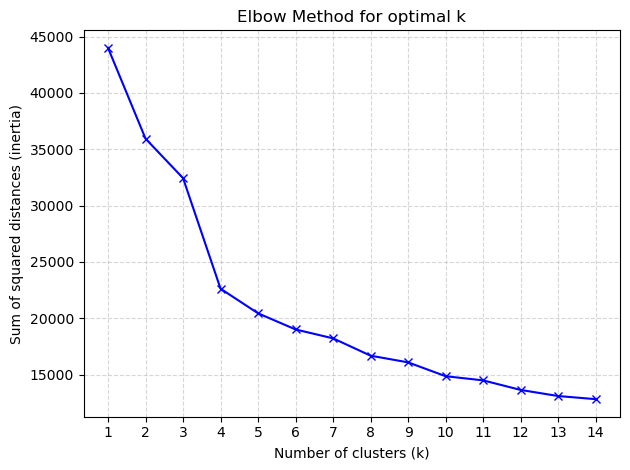

In [37]:
plot_elbow(df, vars_list, k_max=15)

#### Cluster Histogram

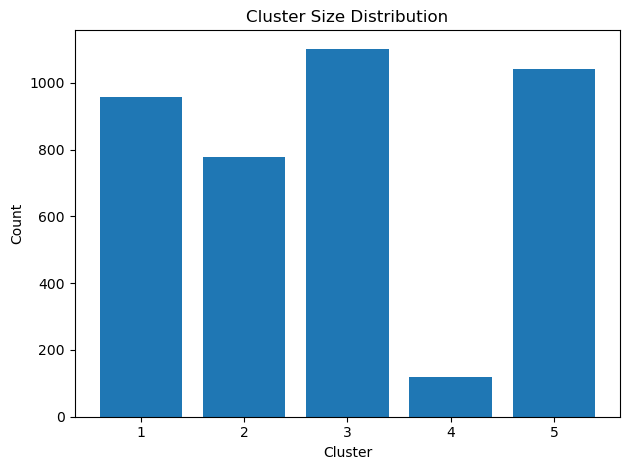

In [10]:
plot_cluster_histogram(df, n_clusters=n)

#### Variable Histograms

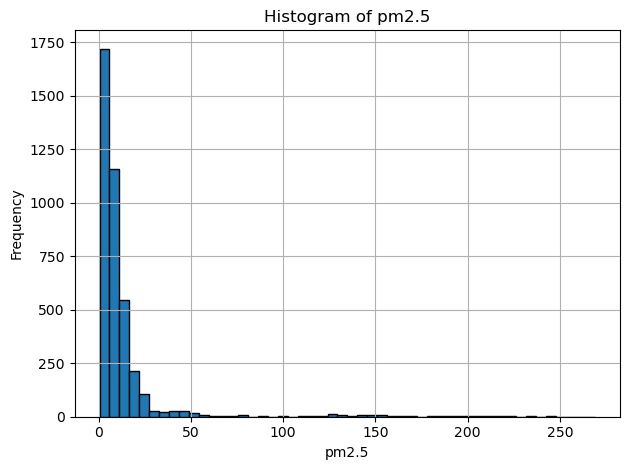

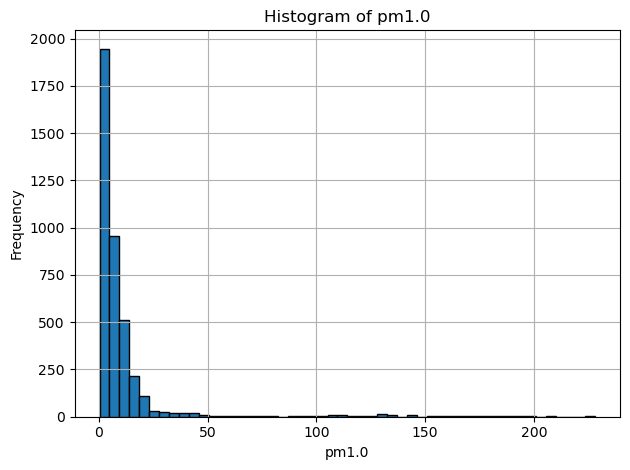

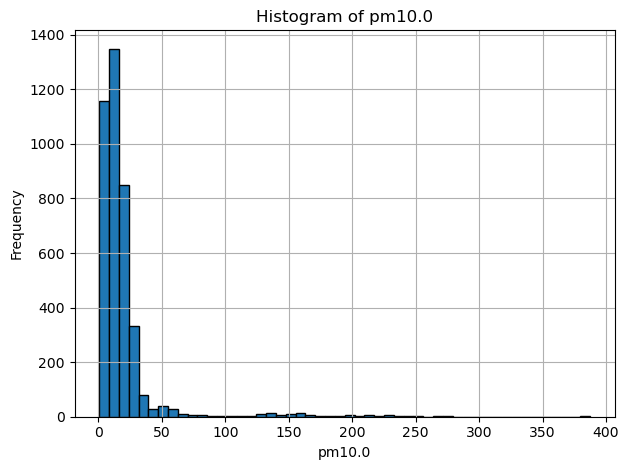

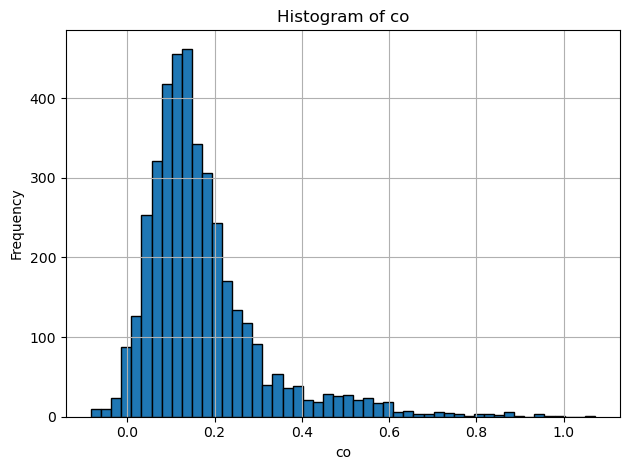

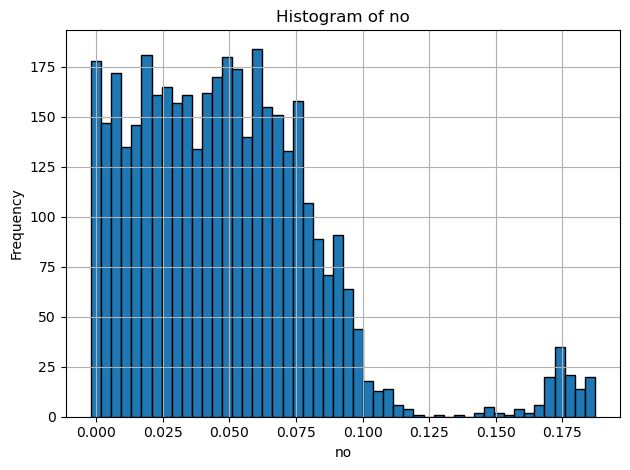

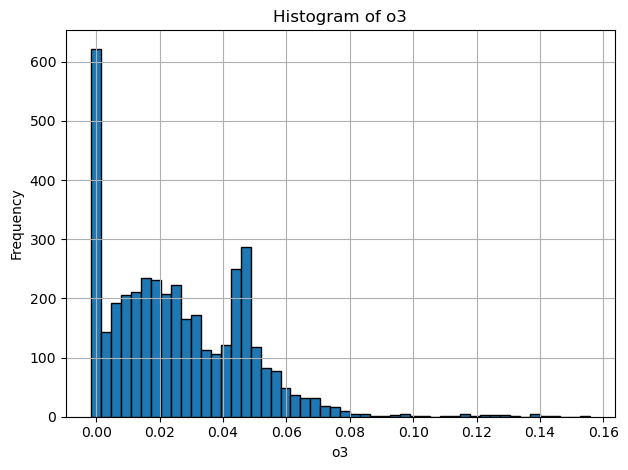

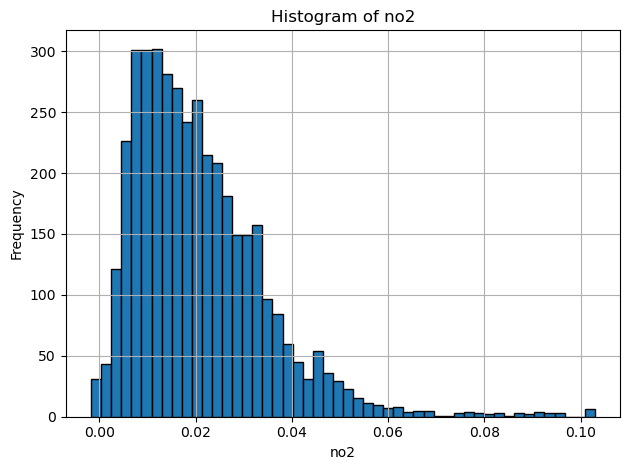

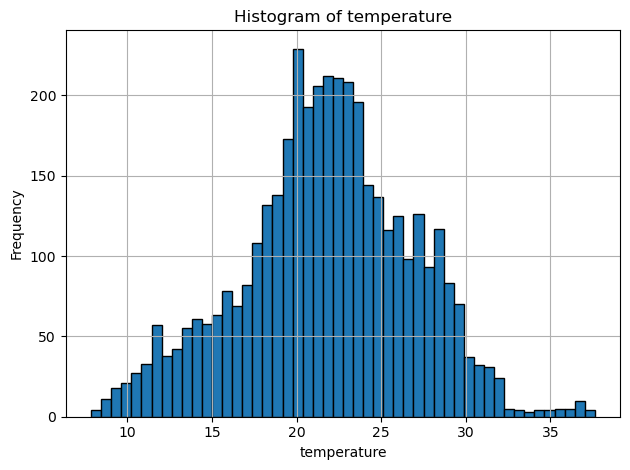

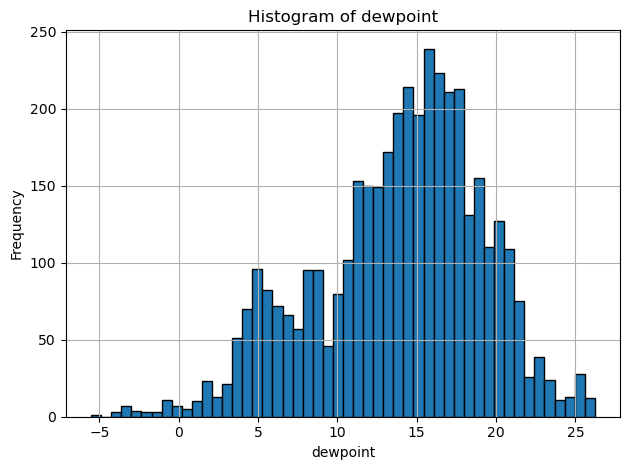

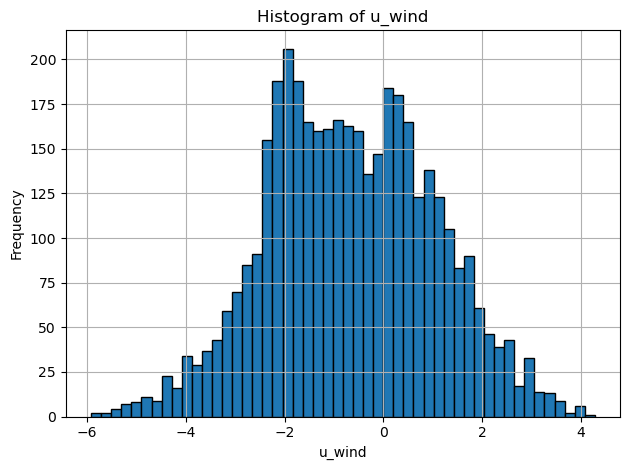

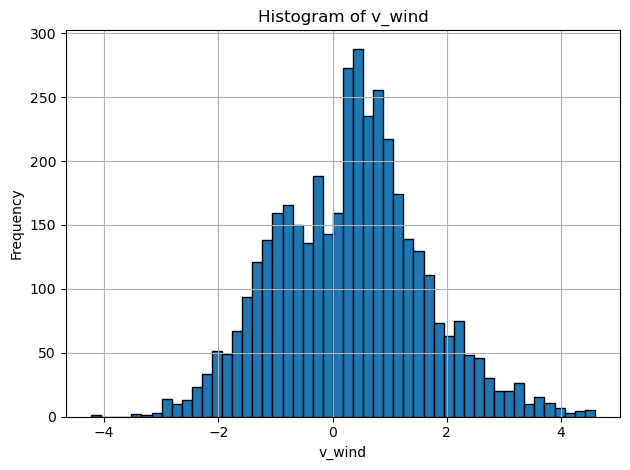

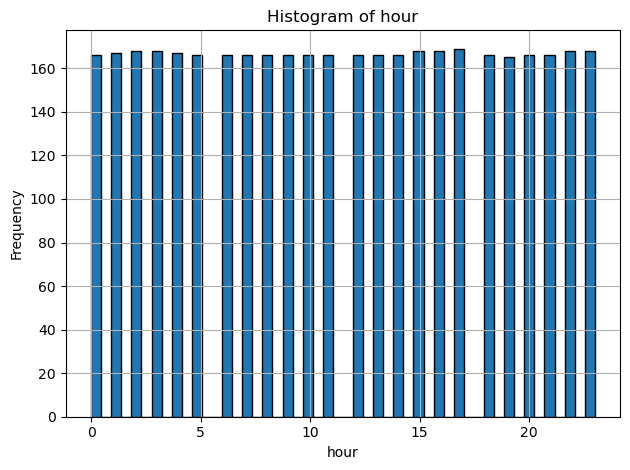

In [6]:
plot_all_variable_histograms(df)

#### Boxplots by Cluster

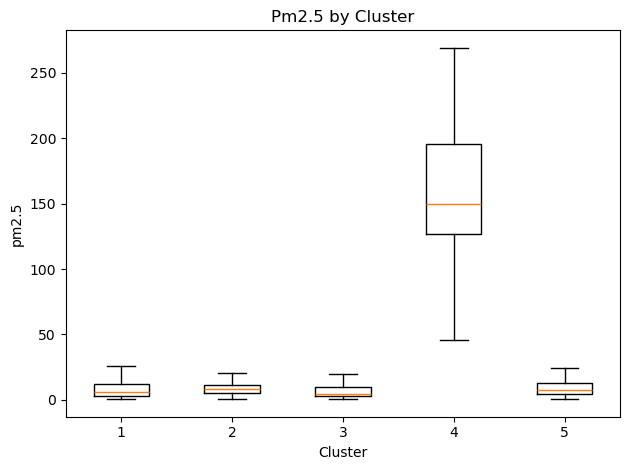

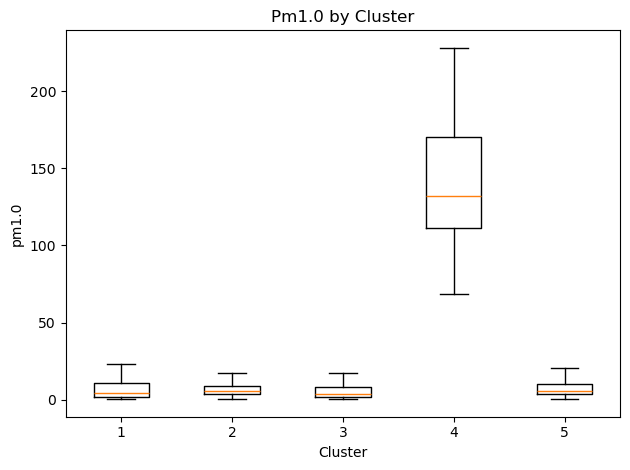

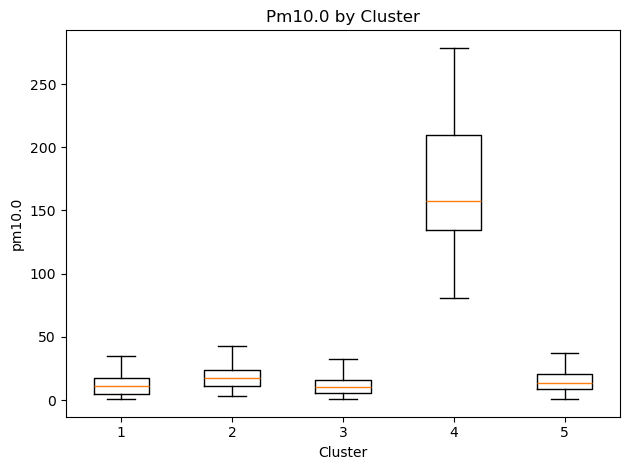

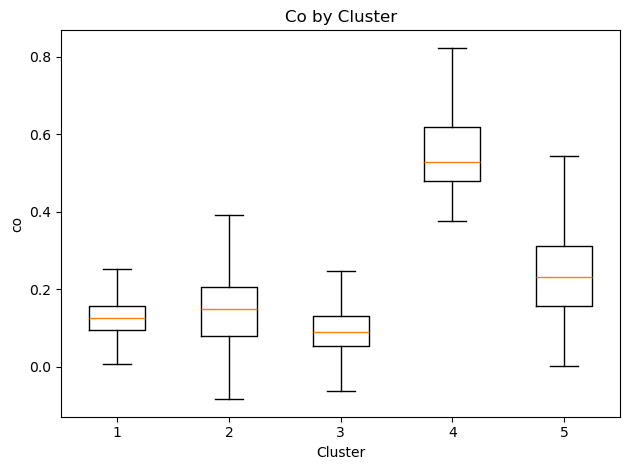

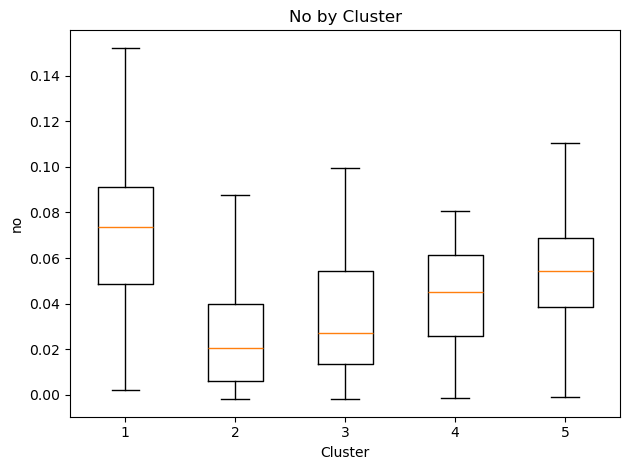

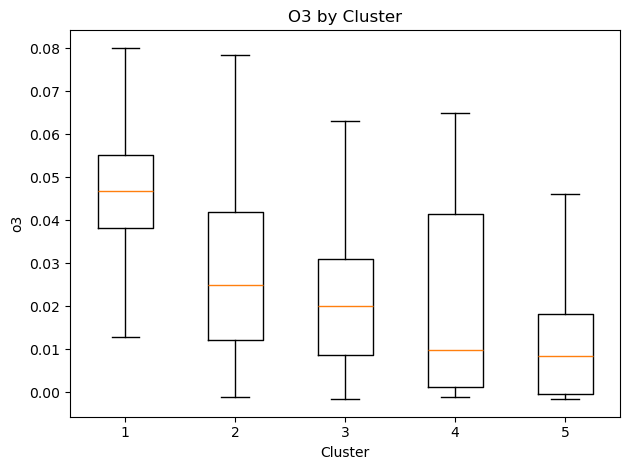

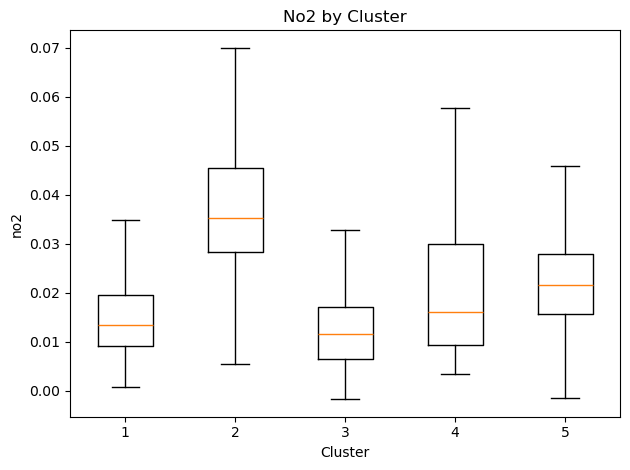

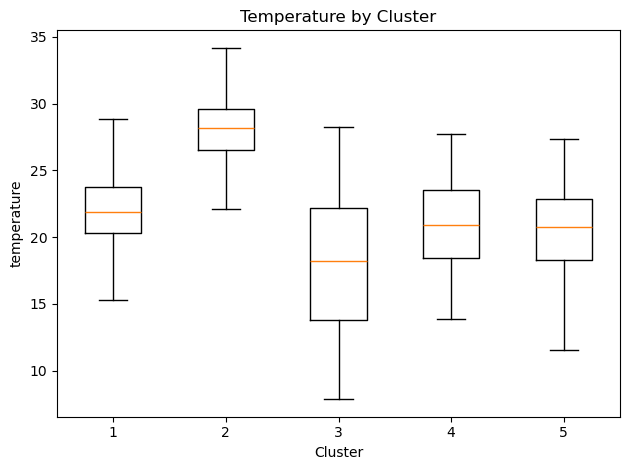

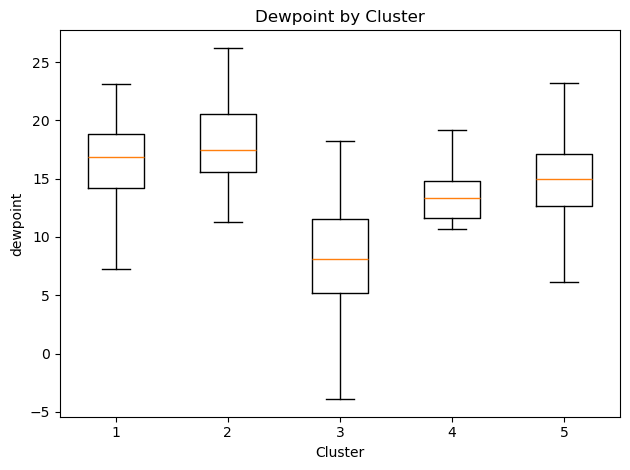

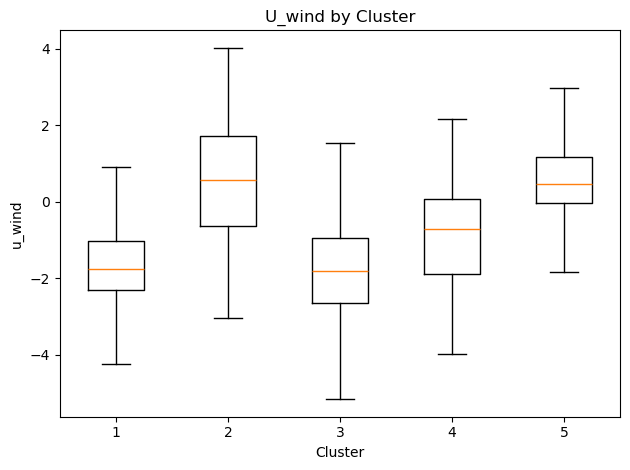

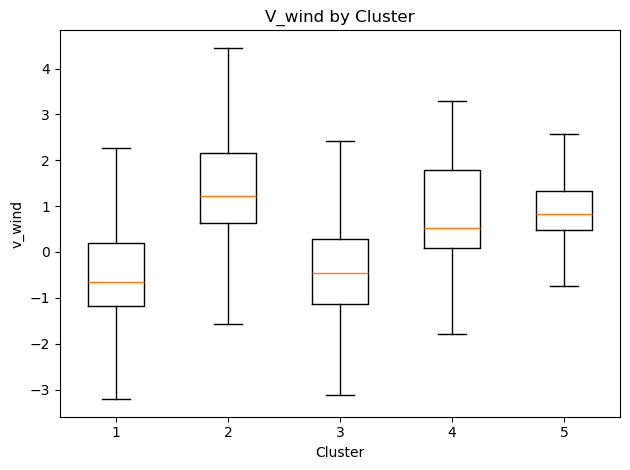

In [11]:
plot_box_time(df, vars_list)

#### Pairplot

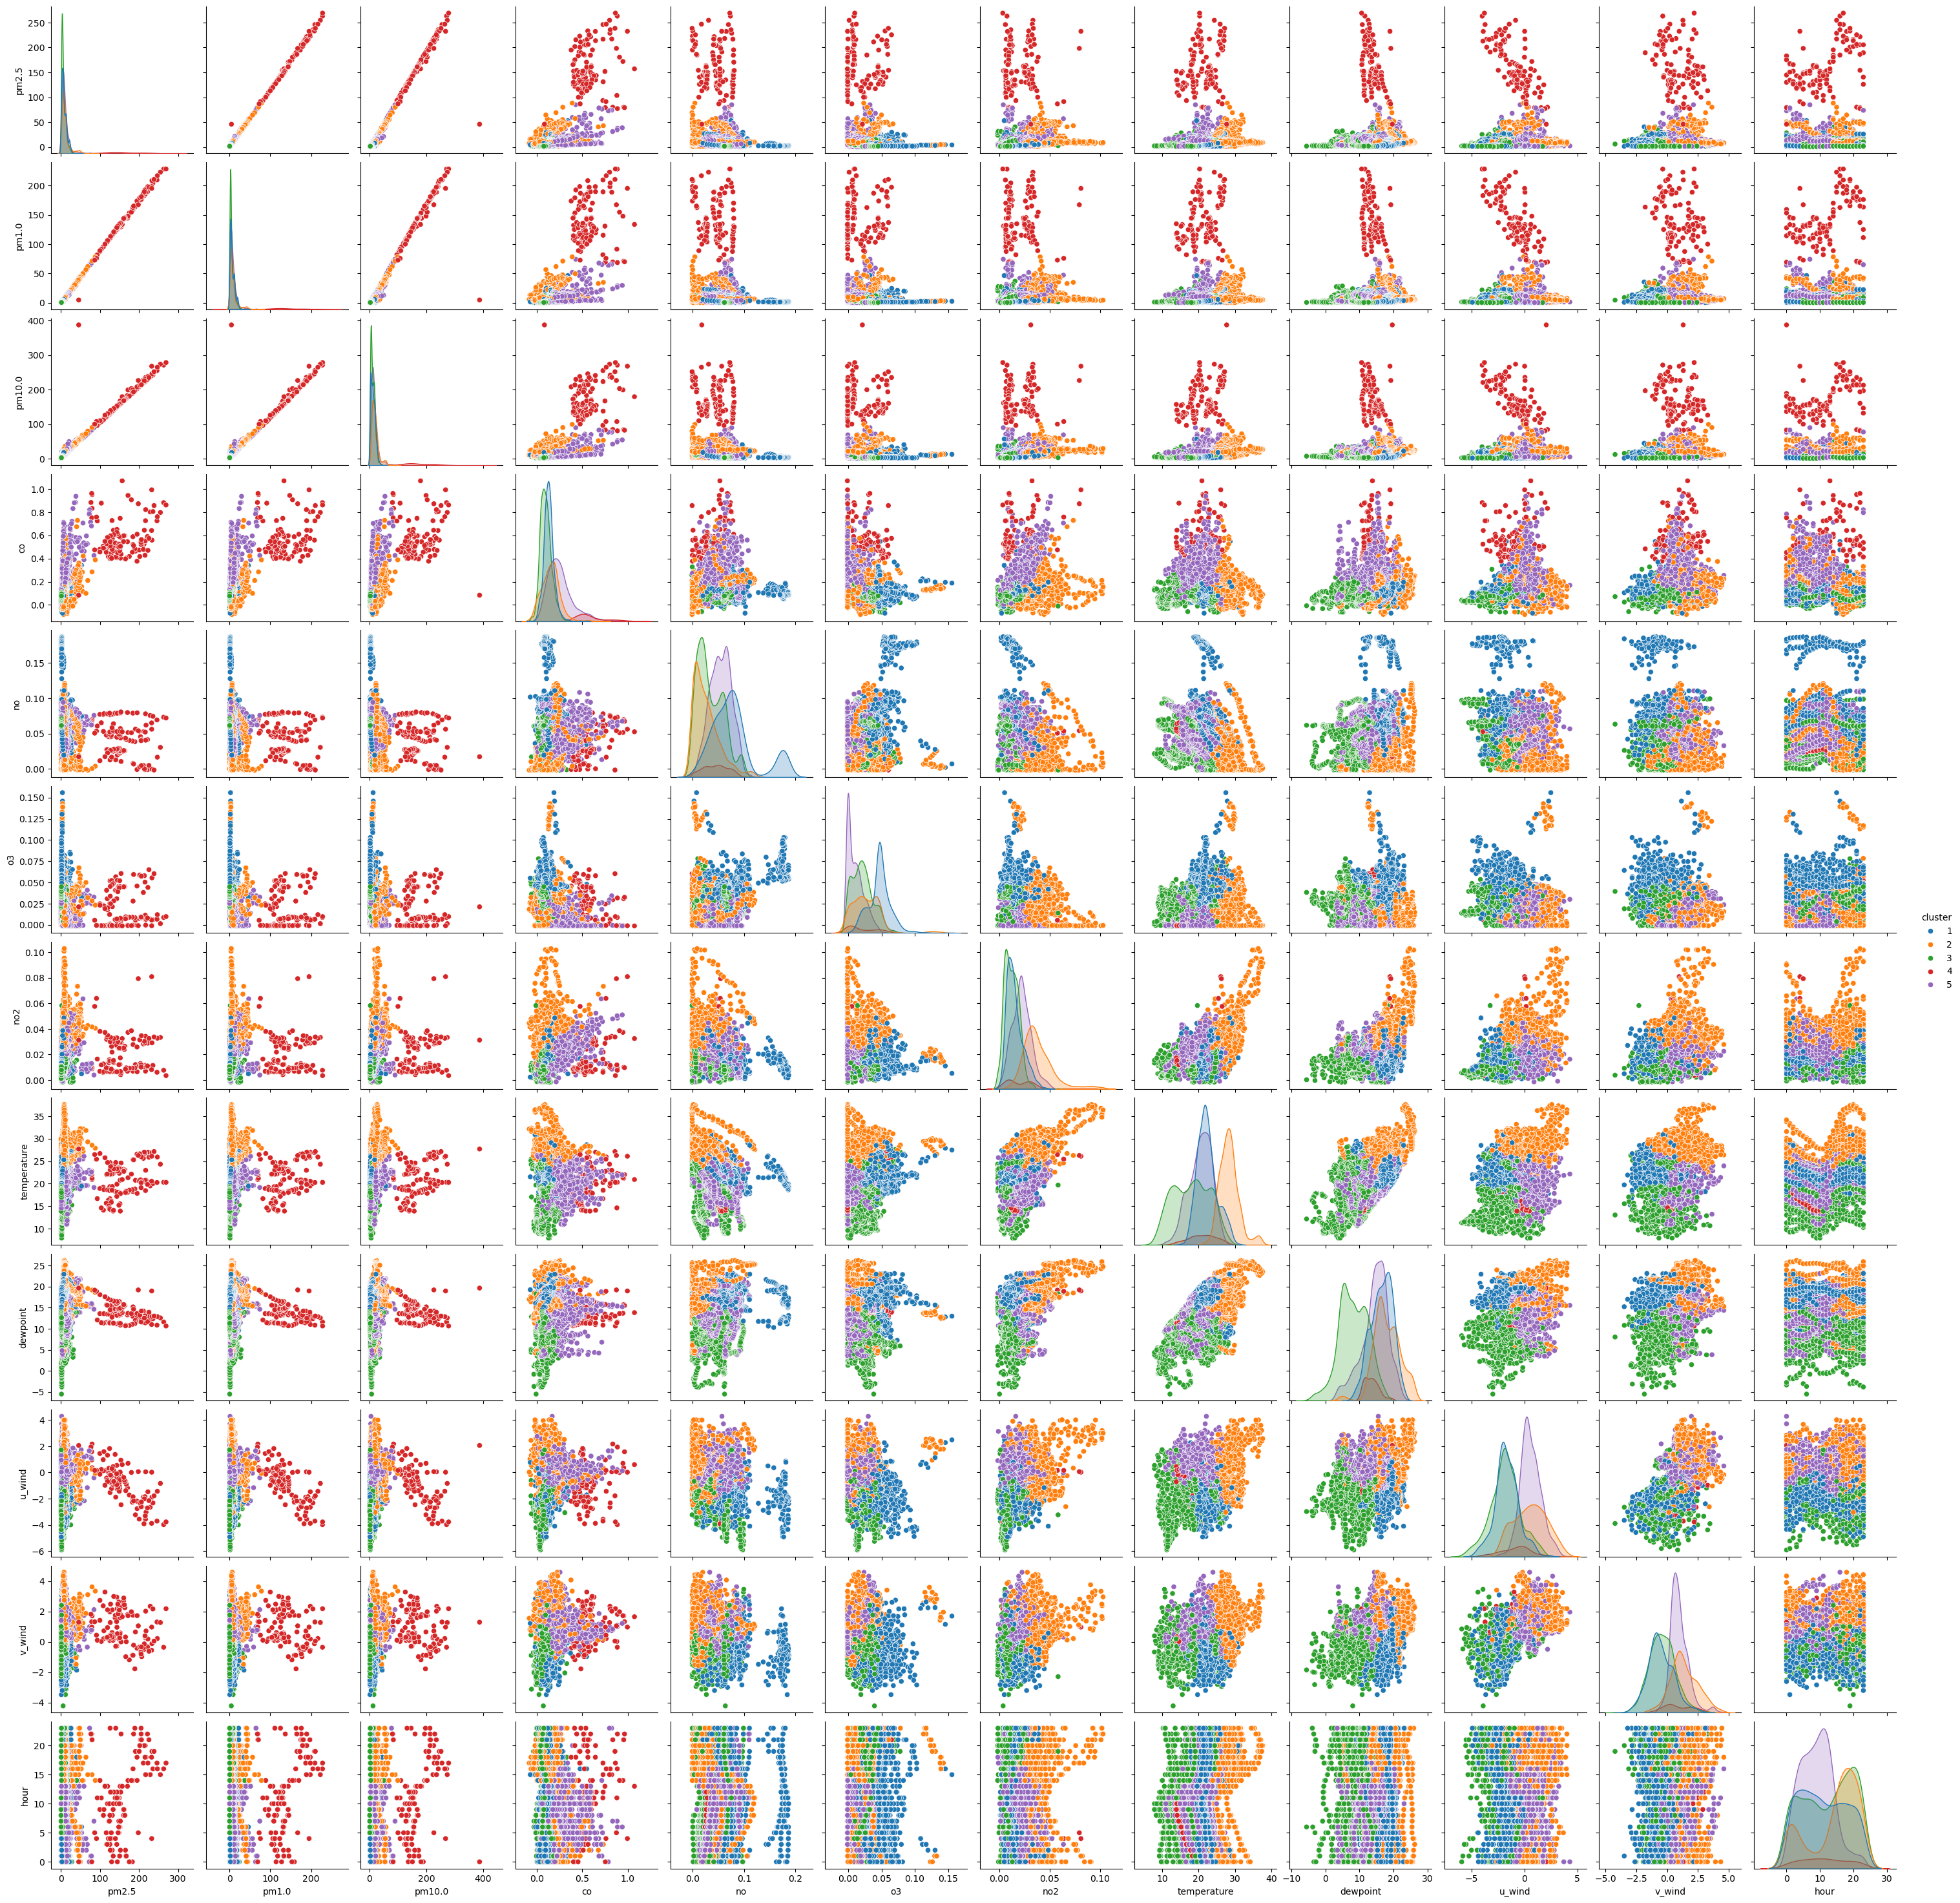

In [12]:
plot_variable_pairs(df, n_clusters=n)

#### Mosaic Plot (Hour vs. Cluster)

<Figure size 800x600 with 0 Axes>

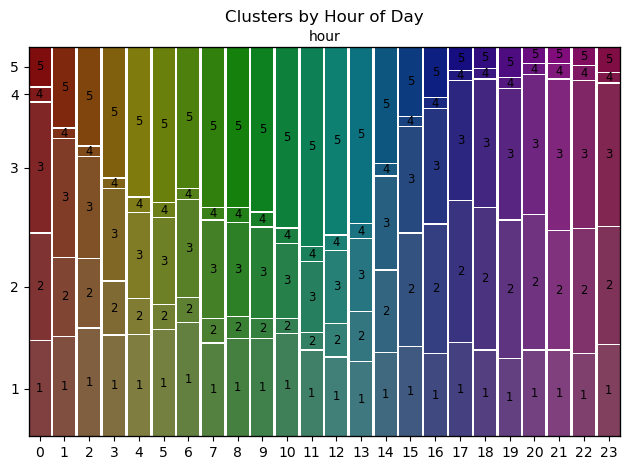

In [13]:
mosaic_plot(df, 'hour', 'cluster', title="Clusters by Hour of Day")

#### Variable Importance Bar Chart

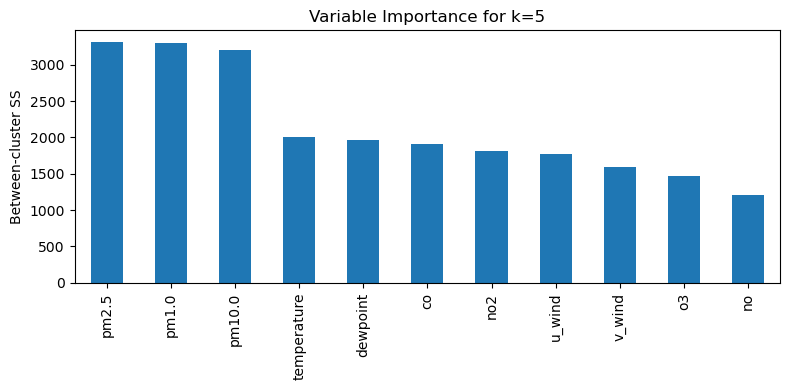

In [22]:
imp = variable_importance_bss(df, vars_list, n_clusters=n)

plt.figure(figsize=(8,4))
imp.plot(kind='bar')
plt.ylabel('Between-cluster SS')
plt.title(f'Variable Importance for k={n}')
plt.tight_layout()
plt.show()

#### Per‐Cluster Treemaps

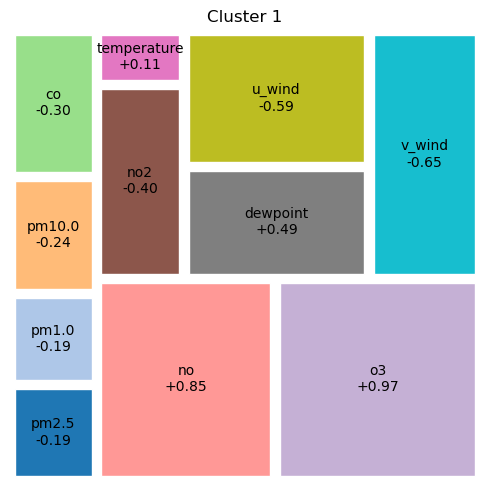

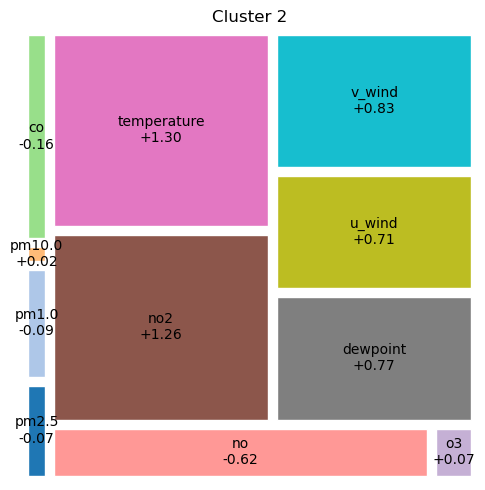

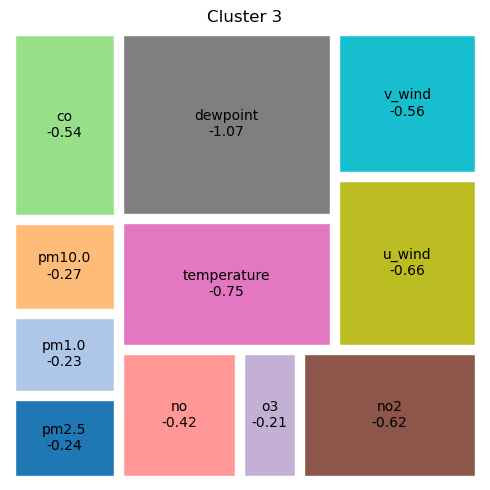

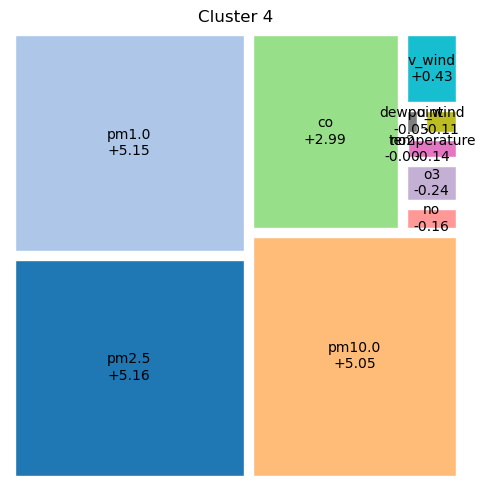

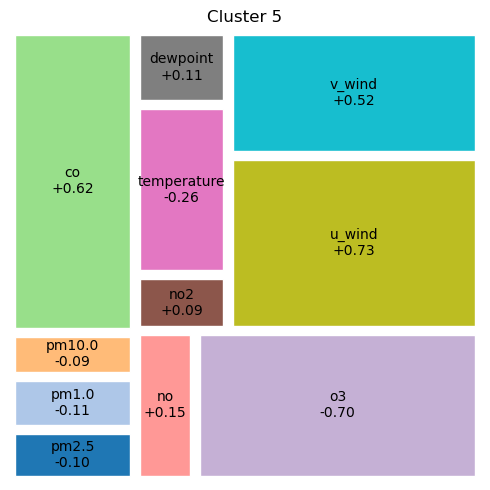

In [43]:
plot_per_cluster_treemaps(km, vars_list, n_clusters=n)

#### All cluster treemaps

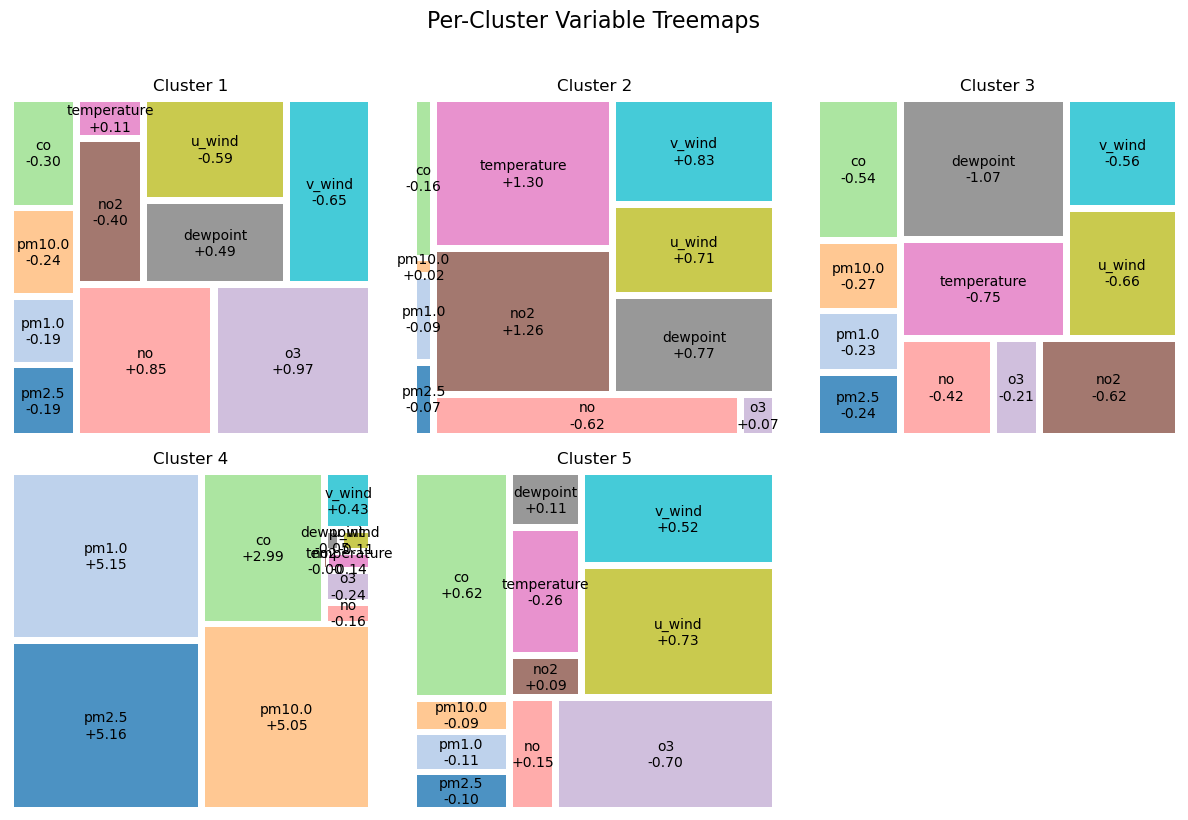

In [47]:
plot_all_cluster_treemaps(km, vars_list, n_clusters=n, cols=3)

#### Overall Treemap (BSS)

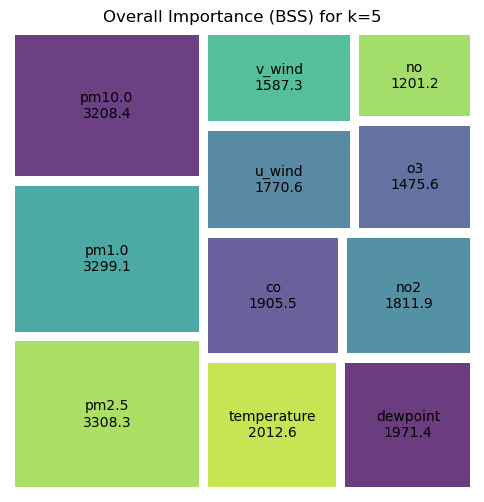

In [19]:
sizes  = imp.values
labels = [f"{v}\n{imp[v]:.1f}" for v in imp.index]

plt.figure(figsize=(6,6))
squarify.plot(sizes=sizes, label=labels, alpha=0.8, pad=True)
plt.title(f'Overall Importance (BSS) for k={n}')
plt.axis('off')
plt.show()

#### Export Cluster Dates

In [25]:
export_cluster_dates(df, cluster_id=nid, filename=f'cluster{nid}_dates.txt')

Saved 1042 timestamps to cluster5_dates.txt


#### Cluster 4 experimentation

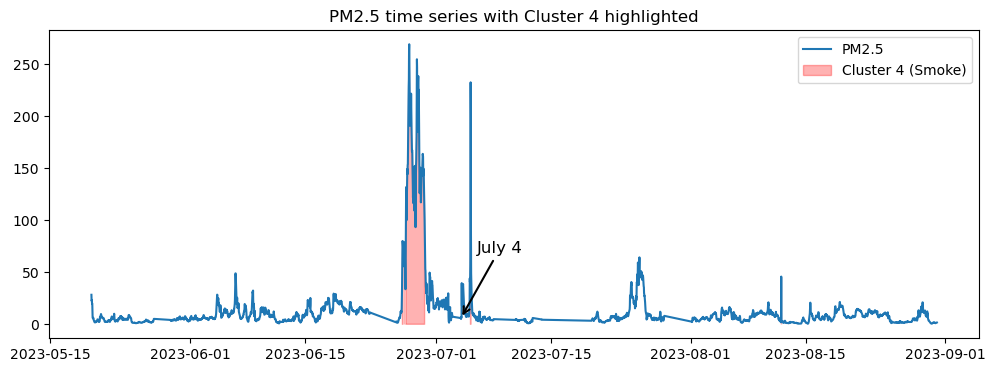

In [30]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['pm2.5'], label='PM2.5')
mask4 = df['cluster']==4
plt.fill_between(df.index, df['pm2.5'], where=mask4,
                 color='red', alpha=0.3, label='Cluster 4 (Smoke)')
# annotate July 4
july4 = pd.Timestamp('2023-07-04')
# pick the PM2.5 value at or just before midnight on July 4
pm25_july4 = df['pm2.5'].asof(july4)

plt.annotate(
    'July 4',
    xy=(july4, pm25_july4),
    xytext=(july4 + pd.Timedelta(days=2), pm25_july4 + 60),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    fontsize=12,
    va='bottom'
)
plt.legend(); plt.title('PM2.5 time series with Cluster 4 highlighted')
plt.show()

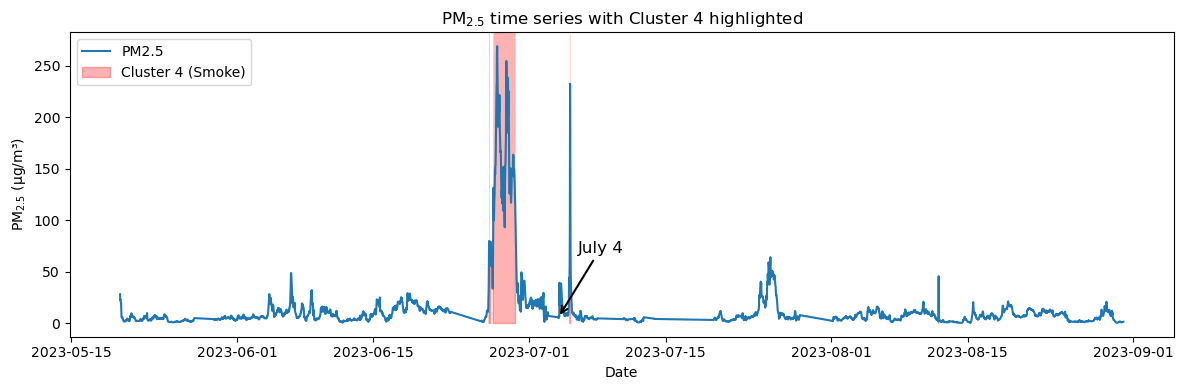

In [19]:
plt.figure(figsize=(12, 4))

# 1) plot PM2.5 on top
plt.plot(df.index, df['pm2.5'], label='PM2.5', linewidth=1.5, zorder=2)

# 2) find where cluster==4
mask4 = (df['cluster'] == 4)

# 3) capture the current y‐limits so we can restore them
ymin, ymax = plt.ylim()

# 4) fill above the curve wherever cluster4 is True
plt.fill_between(
    df.index, df['pm2.5'], ymax,
    where=mask4,
    facecolor='red',
    alpha=0.3,
    interpolate=True
)

plt.fill_between(df.index, df['pm2.5'], where=mask4,
                 color='red', alpha=0.3, label='Cluster 4 (Smoke)', interpolate=True)

# restore y‐limits unchanged
plt.ylim(ymin, ymax)

# 5) annotate “July 4” with an arrow
july4 = pd.Timestamp('2023-07-04')
pm4   = df['pm2.5'].asof(july4)
plt.annotate(
    'July 4',
    xy=(july4, pm4),
    xytext=(july4 + pd.Timedelta(days=2), pm4 + 60),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    fontsize=12,
    va='bottom'
)

plt.legend(loc='upper left')
plt.title('PM$_{2.5}$ time series with Cluster 4 highlighted')
plt.xlabel('Date')
plt.ylabel('PM$_{2.5}$ (µg/m³)')
plt.tight_layout()
plt.show()

#### Clusters 2 and 5 experimentation

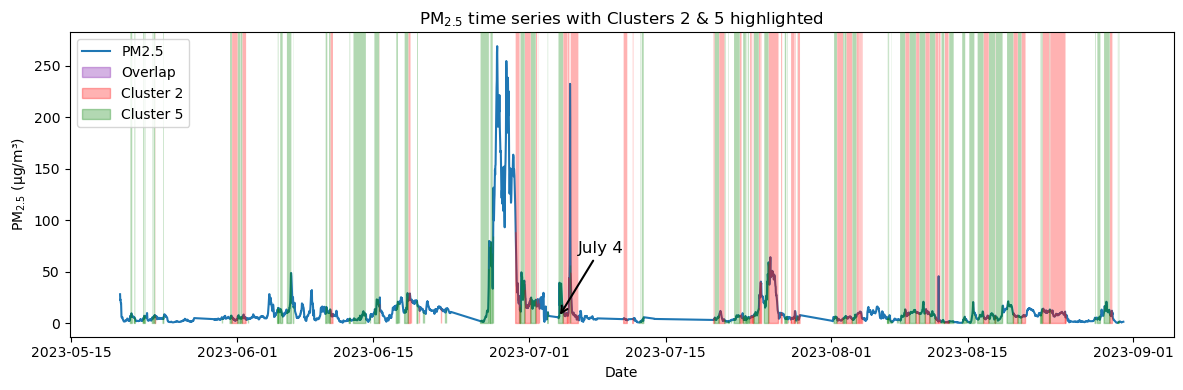

In [18]:
plt.figure(figsize=(12, 4))

# 1) plot PM2.5 on top
plt.plot(df.index, df['pm2.5'], label='PM2.5', linewidth=1.5, zorder=2)

# 2) find where cluster==4
mask2 = (df['cluster'] == 2)
mask5 = (df['cluster'] == 5)
mask_overlap = ((df['cluster']==2) & (df['cluster'] == 5))

mask2_only = mask2 & ~mask_overlap
mask5_only = mask5 & ~mask_overlap

# 3) capture the current y‐limits so we can restore them
ymin, ymax = plt.ylim()

# 4) fill above the curve wherever cluster4 is True
# plt.fill_between(
#     df.index, df['pm2.5'], ymax,
#     where=mask_overlap,
#     facecolor='purple',
#     alpha=0.3,
#     zorder = 4
# )

plt.fill_between(
    df.index, df['pm2.5'], ymax,
    where=mask2_only,
    facecolor='red',
    alpha=0.3,
    zorder = 2
)

plt.fill_between(
    df.index, df['pm2.5'], ymax,
    where=mask5_only,
    facecolor='green',
    alpha=0.3,
    zorder = 3
)
plt.fill_between(
    df.index, df['pm2.5'], ymax,
    where=mask_overlap,
    facecolor='#7200a3',
    alpha=0.3,
    zorder = 6
)

# 5) fill below the curve
plt.fill_between(df.index, df['pm2.5'], where=mask_overlap,
                 color='#7200a3', alpha=0.3, label='Overlap', zorder = 4)

plt.fill_between(df.index, df['pm2.5'], where=mask2_only,
                 color='red', alpha=0.3, label='Cluster 2', zorder = 2)

plt.fill_between(df.index, df['pm2.5'], where=mask5_only,
                 color='green', alpha=0.3, label='Cluster 5', zorder = 3)

# plt.fill_between(df.index, df['pm2.5'], where=mask_overlap,
#                  color='purple', alpha=1, label='Overlap', zorder = 1)

# restore y‐limits unchanged
plt.ylim(ymin, ymax)

# 6) annotate “July 4” with an arrow
july4 = pd.Timestamp('2023-07-04')
pm4   = df['pm2.5'].asof(july4)
plt.annotate(
    'July 4',
    xy=(july4, pm4),
    xytext=(july4 + pd.Timedelta(days=2), pm4 + 60),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    fontsize=12,
    va='bottom'
)

plt.legend(loc='upper left')
plt.title('PM$_{2.5}$ time series with Clusters 2 & 5 highlighted')
plt.xlabel('Date')
plt.ylabel('PM$_{2.5}$ (µg/m³)')
plt.tight_layout()
plt.show()

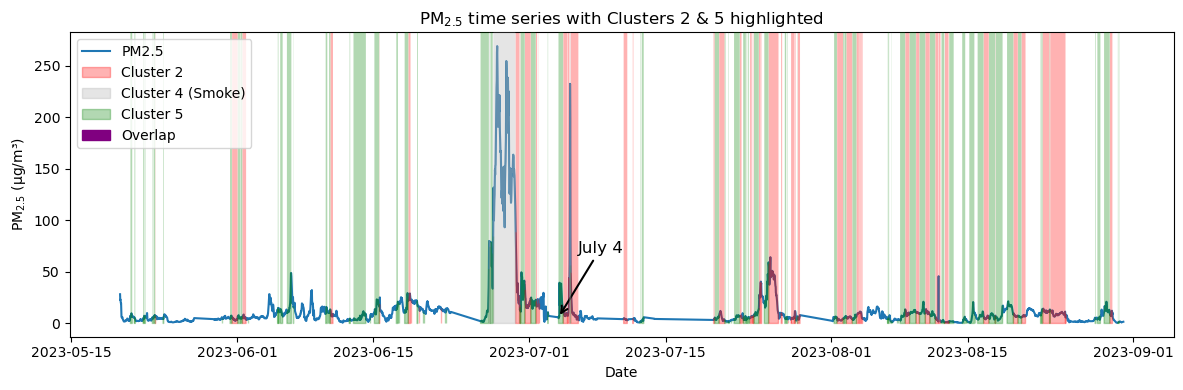

In [25]:
plt.figure(figsize=(12, 4))

# 1) plot PM2.5 on top
plt.plot(df.index, df['pm2.5'], label='PM2.5', linewidth=1.5, zorder=2)

# 2) find where cluster==4
mask1 = (df['cluster'] == 1)
mask2 = (df['cluster'] == 2)
mask3 = (df['cluster'] == 3)
mask4 = (df['cluster'] == 4)
mask5 = (df['cluster'] == 5)
mask_overlap = ((df['cluster']==2) & (df['cluster'] == 5))

mask2_only = mask2 & ~mask_overlap
mask5_only = mask5 & ~mask_overlap

# 3) capture the current y‐limits so we can restore them
ymin, ymax = plt.ylim()

# 4) fill above the curve wherever cluster4 is True

plt.fill_between(
    df.index, df['pm2.5'], ymax,
    where=mask2,
    facecolor='red',
    alpha=0.3,
    zorder = 2
)

plt.fill_between(
    df.index, df['pm2.5'], ymax,
    where=mask4,
    facecolor='darkgray',
    alpha=0.3,
    zorder = 4
)

plt.fill_between(
    df.index, df['pm2.5'], ymax,
    where=mask5,
    facecolor='green',
    alpha=0.3,
    zorder = 3
)
plt.fill_between(
    df.index, df['pm2.5'], ymax,
    where=mask_overlap,
    facecolor='#7200a3',
    alpha=0.3,
    zorder = 0
)

# 5) fill below the curve
# plt.fill_between(df.index, df['pm2.5'], where=mask_overlap,
#                  color='#7200a3', alpha=0.3, label='Overlap', zorder = 4)

plt.fill_between(df.index, df['pm2.5'], where=mask2,
                 color='red', alpha=0.3, label='Cluster 2', zorder = 2)

plt.fill_between(df.index, df['pm2.5'], where=mask4,
                 color='darkgray', alpha=0.3, label='Cluster 4 (Smoke)', zorder = 4)

plt.fill_between(df.index, df['pm2.5'], where=mask5,
                 color='green', alpha=0.3, label='Cluster 5', zorder = 3)

plt.fill_between(df.index, df['pm2.5'], where=mask_overlap,
                 color='purple', alpha=1, label='Overlap', zorder = 0)


# restore y‐limits unchanged
plt.ylim(ymin, ymax)

# 6) annotate “July 4” with an arrow
july4 = pd.Timestamp('2023-07-04')
pm4   = df['pm2.5'].asof(july4)
plt.annotate(
    'July 4',
    xy=(july4, pm4),
    xytext=(july4 + pd.Timedelta(days=2), pm4 + 60),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    fontsize=12,
    va='bottom'
)

plt.legend(loc='upper left')
plt.title('PM$_{2.5}$ time series with Clusters 2 & 5 highlighted')
plt.xlabel('Date')
plt.ylabel('PM$_{2.5}$ (µg/m³)')
plt.tight_layout()
plt.show()

#### Cluster 4 versus background

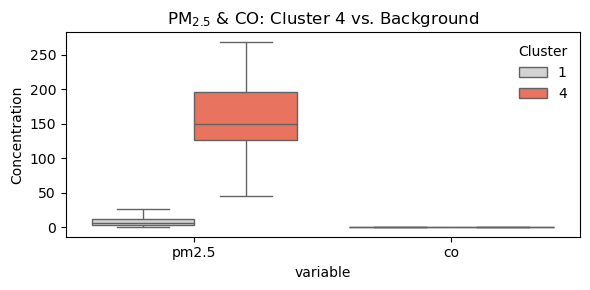

In [30]:
plt.figure(figsize=(6,3))
# melt only PM2.5 and CO for brevity
m = df[['cluster','pm2.5','co']].query('cluster in [1,4]').melt(
    id_vars='cluster',
    var_name='variable',
    value_name='value'
)
sns.boxplot(x='variable', y='value', hue='cluster', data=m,
            palette={1:'lightgray',4:'tomato'}, fliersize=0)
plt.ylabel('Concentration')
plt.title('PM$_{2.5}$ & CO: Cluster 4 vs. Background')
plt.legend(title='Cluster', loc='upper right', frameon=False)
plt.tight_layout()


C:\Users\video\AppData\Local\Temp\ipykernel_34076\1261578104.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\video\AppData\Local\Temp\ipykernel_34076\1261578104.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


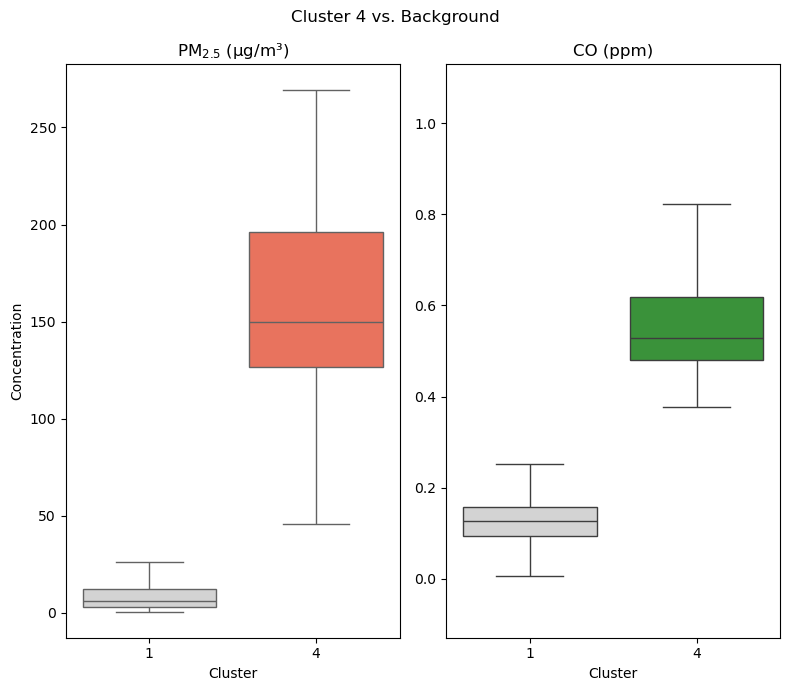

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8,7), sharey=False)

# PM2.5 panel
sns.boxplot(
    x='cluster', y='pm2.5',
    data=df[df.cluster.isin([1,4])],
    order=[1,4],
    palette=['lightgray','tomato'],
    fliersize=0,
    ax=axes[0]
)
axes[0].set_title('PM$_{2.5}$ (µg/m³)')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Concentration')

# CO panel
sns.boxplot(
    x='cluster', y='co',
    data=df[df.cluster.isin([1,4])],
    order=[1,4],
    palette=['lightgray','tab:green'],
    fliersize=0,
    ax=axes[1]
)
axes[1].set_title('CO (ppm)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('')

fig.suptitle('Cluster 4 vs. Background')
plt.tight_layout(rect=[0,0,1,1])
plt.savefig('output.png')
plt.show()

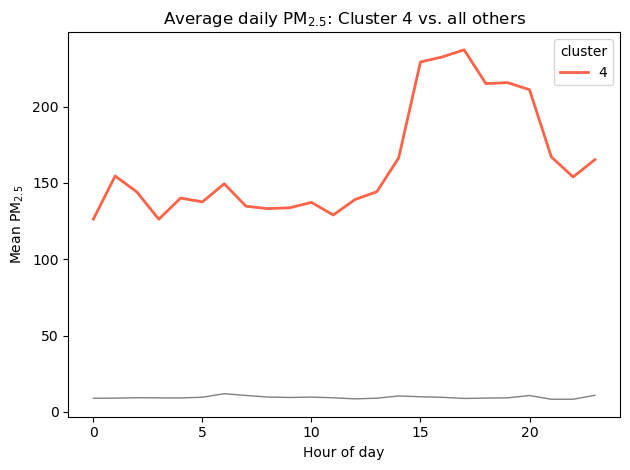

In [39]:
hourly = df.groupby(['hour','cluster'])['pm2.5'].mean().unstack()
hourly[[4]].plot(kind='line', lw=2, color='tomato', legend=True)
hourly.drop(columns=4).mean(axis=1).plot(lw=1, color='gray')
plt.xlabel('Hour of day')
plt.ylabel('Mean PM$_{2.5}$')
plt.title('Average daily PM$_{2.5}$: Cluster 4 vs. all others')
plt.tight_layout()


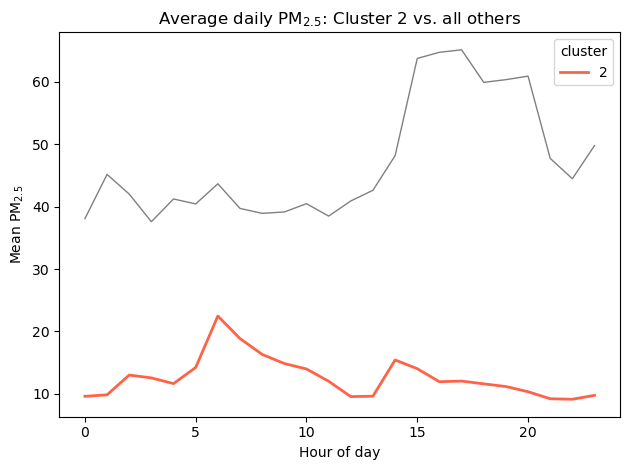

In [45]:
hourly = df.groupby(['hour','cluster'])['pm2.5'].mean().unstack()
hourly[[2]].plot(kind='line', lw=2, color='tomato', legend=True)
hourly.drop(columns=2).mean(axis=1).plot(lw=1, color='gray')
plt.xlabel('Hour of day')
plt.ylabel('Mean PM$_{2.5}$')
plt.title('Average daily PM$_{2.5}$: Cluster 2 vs. all others')
plt.tight_layout()


#### Export netCDF

In [3]:
ds_out = df.to_xarray()
# vars_list_exp = ['pm2.5','pm1.0','pm10.0','co','no','o3','no2','temperature','dewpoint','u_wind','v_wind']
time_frame_for_exp = 30 # change this for the dataset that is being exported

In [4]:
output_dir = "C://Users//video//Documents//My Project//summer2025//Brandon_Swanson"

new_file_name = f"crocus_neiu_merged_{time_frame_for_exp}min.nc"
output_file_path = os.path.join(output_dir, new_file_name)

# Save the resampled data to a new netCDF file
ds_out.to_netcdf(output_file_path)
print(f"Resampled data saved to {output_file_path}")

Resampled data saved to C://Users//video//Documents//My Project//summer2025//Brandon_Swanson\crocus_neiu_merged_30min.nc


In [5]:
test = xr.open_dataset("C://Users//video//Documents//My Project//summer2025//Brandon_Swanson//crocus_neiu_merged_30min.nc", engine='netcdf4')
test

<xarray.Dataset> Size: 416kB
Dimensions:      (index: 4000)
Coordinates:
  * index        (index) int64 32kB 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
Data variables:
    pm2.5        (index) float64 32kB ...
    pm1.0        (index) float64 32kB ...
    pm10.0       (index) float64 32kB ...
    co           (index) float64 32kB ...
    no           (index) float64 32kB ...
    o3           (index) float64 32kB ...
    no2          (index) float64 32kB ...
    temperature  (index) float64 32kB ...
    dewpoint     (index) float64 32kB ...
    u_wind       (index) float64 32kB ...
    v_wind       (index) float64 32kB ...
    time         (index) datetime64[ns] 32kB ...

In [15]:
testnew = test.to_pandas
testnew().head(10)

,pm2.5,pm1.0,pm10.0,co,no,o3,no2,temperature,dewpoint,u_wind,v_wind,time
index,,,,,,,,,,,,
0,28.350000,24.050000,35.450000,0.218233,0.012033,0.027467,0.013567,15.220000,7.995897,-1.607238,-1.670666,2023-05-20 00:00:00
1,22.733333,19.316667,28.150000,0.179633,0.012567,0.022667,0.009133,14.220000,6.396147,-1.808306,-1.944357,2023-05-20 00:30:00
2,23.266667,19.966667,28.416667,0.173333,0.013800,0.020900,0.010767,13.826667,6.456700,-2.156636,-1.122327,2023-05-20 01:00:00
3,20.916667,17.783333,25.566667,0.179433,0.016300,0.022067,0.010200,13.553333,6.554624,-1.531059,0.653497,2023-05-20 01:30:00
4,19.633333,16.633333,23.583333,0.185333,0.017000,0.022133,0.008800,13.440000,6.589255,-0.022842,1.309572,2023-05-20 02:00:00
5,19.766667,17.050000,24.183333,0.183633,0.017033,0.014800,0.010433,13.460000,6.446772,0.082459,1.277045,2023-05-20 02:30:00
6,12.483333,10.800000,15.716667,0.151800,0.016567,0.010233,0.008633,13.570000,5.430516,1.347791,0.207419,2023-05-20 03:00:00
7,6.500000,5.566667,10.016667,0.114400,0.016900,0.008167,0.006300,13.543333,4.768541,1.027464,0.835463,2023-05-20 03:30:00
8,5.966667,5.150000,9.050000,0.095667,0.017167,0.006633,0.005833,13.243333,4.581238,1.207284,0.447844,2023-05-20 04:00:00
